In [1]:

# ============================================================
# CELL 1 — IMPORT DEPENDENCIES
# Applicability Domain (AD) Analysis
# Target: EGFR & BRAF
# ============================================================

# Standard library
import os
import sys
import json
import pickle
import joblib
import warnings
from pathlib import Path

# Numerical computation
import numpy as np

# Data manipulation
import pandas as pd

# Molecular processing and fingerprint
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors

# Machine learning: model loading and evaluation
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Similarity and distance
from scipy.spatial.distance import cdist

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display and formatting
from IPython.display import display

# Suppress unnecessary warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("All imports completed.")
print("NumPy version :", np.__version__)
print("Pandas version:", pd.__version__)
print("Random seed   :", SEED)


All imports completed.
NumPy version : 2.3.5
Pandas version: 2.3.3
Random seed   : 42


In [2]:

# ============================================================
# CELL 2 — PROJECT PATHS & FILE INSPECTION
# ============================================================

# Cari root proyek dari working directory dan parent-nya
cwd = Path.cwd().resolve()
search_roots = [cwd, *cwd.parents]

PROJECT_ROOT = None

for root in search_roots:
    if (
        (root / "dataset" / "dataset_features").is_dir()
        and (root / "kaggle" / "1" / "baseline_models").is_dir()
    ):
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    print("Working directory:", cwd)
    print("\nFolder di working directory:")
    for path in cwd.iterdir():
        print(" -", path.name)

    raise FileNotFoundError(
        "Root proyek tidak ditemukan. "
        "Pastikan dataset/dataset_features dan "
        "kaggle/1/baseline_models berada di bawah root proyek."
    )

# Konfigurasi direktori
DATA_DIR = PROJECT_ROOT / "dataset" / "dataset_features"
MODEL_DIR = PROJECT_ROOT / "kaggle" / "1" / "baseline_models"
SPLIT_DIR = PROJECT_ROOT / "kaggle" / "1" / "split_indices"

print("=" * 65)
print("PROJECT CONFIGURATION")
print("=" * 65)
print("Working directory :", cwd)
print("Project root      :", PROJECT_ROOT)
print("Dataset features  :", DATA_DIR)
print("Baseline models   :", MODEL_DIR)
print("Split indices     :", SPLIT_DIR)
print("Split folder exists:", SPLIT_DIR.is_dir())

# ------------------------------------------------------------
# A. Periksa dataset fitur
# ------------------------------------------------------------
print("\n" + "=" * 65)
print("DATASET FEATURES")
print("=" * 65)

for path in sorted(DATA_DIR.glob("*.csv")):
    df_preview = pd.read_csv(path, nrows=3)

    print(f"\nFile          : {path.name}")
    print("Kolom         :", len(df_preview.columns))
    print("Contoh kolom  :", list(df_preview.columns[:12]))
    print("Kolom terakhir:", list(df_preview.columns[-12:]))

# ------------------------------------------------------------
# B. Periksa model dan metadata tersimpan
# ------------------------------------------------------------
print("\n" + "=" * 65)
print("BASELINE MODELS & METADATA")
print("=" * 65)

for path in sorted(MODEL_DIR.rglob("*")):
    if path.is_file():
        size_kb = path.stat().st_size / 1024
        print(f"{path.relative_to(MODEL_DIR)} ({size_kb:.1f} KB)")

# ------------------------------------------------------------
# C. Periksa split indices
# ------------------------------------------------------------
print("\n" + "=" * 65)
print("SPLIT INDICES")
print("=" * 65)

if SPLIT_DIR.is_dir():
    files = sorted(p for p in SPLIT_DIR.rglob("*") if p.is_file())

    if files:
        for path in files:
            print(
                f"{path.relative_to(SPLIT_DIR)} "
                f"({path.stat().st_size / 1024:.1f} KB)"
            )
    else:
        print("Folder tersedia, tetapi belum ada file.")
else:
    print("Folder split_indices tidak ditemukan.")


PROJECT CONFIGURATION
Working directory : D:\1. UNIV\1. Materi Univ\TUGAS AKHIR\TA\Source Code\Eksperimen
Project root      : D:\1. UNIV\1. Materi Univ\TUGAS AKHIR\TA\Source Code
Dataset features  : D:\1. UNIV\1. Materi Univ\TUGAS AKHIR\TA\Source Code\dataset\dataset_features
Baseline models   : D:\1. UNIV\1. Materi Univ\TUGAS AKHIR\TA\Source Code\kaggle\1\baseline_models
Split indices     : D:\1. UNIV\1. Materi Univ\TUGAS AKHIR\TA\Source Code\kaggle\1\split_indices
Split folder exists: True

DATASET FEATURES

File          : BRAF_features_ECFP4_DESC.csv
Kolom         : 2061
Contoh kolom  : ['canonical_smiles', 'molecule_chembl_id', 'pIC50', 'ECFP4_0', 'ECFP4_1', 'ECFP4_2', 'ECFP4_3', 'ECFP4_4', 'ECFP4_5', 'ECFP4_6', 'ECFP4_7', 'ECFP4_8']
Kolom terakhir: ['ECFP4_2046', 'ECFP4_2047', 'MW', 'HeavyAtomCount', 'MolarRefractivity', 'HBA', 'RotatableBondCount', 'LogP', 'HBD', 'FractionCSP3', 'AromaticHeavyAtomCount', 'TPSA']

File          : EGFR_features_ECFP4_DESC.csv
Kolom         : 2061


In [3]:

# ============================================================
# CELL 3 — INSPECT MODEL METADATA & SPLIT INDICES
# ============================================================

# 1. Metadata seluruh baseline model
print("=" * 75)
print("BASELINE MODEL METADATA")
print("=" * 75)

metadata_path = MODEL_DIR / "metadata" / "baseline_model_metadata.csv"

if metadata_path.exists():
    model_metadata = pd.read_csv(metadata_path)

    print("Columns:")
    print(model_metadata.columns.tolist())

    print("\nMetadata:")
    display(model_metadata)

else:
    print("File metadata tidak ditemukan:", metadata_path)


# 2. Periksa JSON metadata model
print("\n" + "=" * 75)
print("MODEL JSON METADATA")
print("=" * 75)

for target in ["EGFR", "BRAF"]:
    for split in ["random", "scaffold"]:
        json_path = (
            MODEL_DIR
            / split
            / target
            / f"{target}_{split}_random_forest_seed42.json"
        )

        print(f"\n--- {target} | {split} ---")

        if json_path.exists():
            with open(json_path, "r", encoding="utf-8") as f:
                metadata = json.load(f)

            print(json.dumps(metadata, indent=2, default=str))
        else:
            print("JSON tidak ditemukan:", json_path)


# 3. Periksa isi file indeks split
print("\n" + "=" * 75)
print("SPLIT INDICES CONTENT")
print("=" * 75)

for target in ["EGFR", "BRAF"]:
    for split in ["random", "scaffold"]:
        npz_path = SPLIT_DIR / f"{target}_{split}.npz"

        print(f"\n--- {target} | {split} ---")

        if not npz_path.exists():
            print("File tidak ditemukan:", npz_path)
            continue

        with np.load(npz_path, allow_pickle=False) as archive:
            print("Keys:", archive.files)

            for key in archive.files:
                arr = archive[key]

                print(
                    f"{key}: shape={arr.shape}, "
                    f"dtype={arr.dtype}"
                )

                if arr.size <= 30:
                    print("Values:", arr.tolist())
                elif arr.ndim == 1:
                    print("First 10:", arr[:10].tolist())


# 4. Ringkasan split bila tersedia
print("\n" + "=" * 75)
print("SPLIT SUMMARY")
print("=" * 75)

summary_path = SPLIT_DIR / "split_summary.csv"

if summary_path.exists():
    split_summary = pd.read_csv(summary_path)
    print("Columns:", split_summary.columns.tolist())
    display(split_summary)
else:
    print("split_summary.csv tidak ditemukan.")


BASELINE MODEL METADATA
Columns:
['Target', 'Split', 'Seed', 'Model', 'Features', 'Train_Size', 'Test_Size', 'R2', 'RMSE', 'MAE', 'Train_Time_sec', 'Model_Path', 'Metadata_Path']

Metadata:


,Target,Split,Seed,Model,Features,Train_Size,Test_Size,R2,RMSE,MAE,Train_Time_sec,Model_Path,Metadata_Path
0,EGFR,Random,42,Random Forest,2058,8243,2061,0.693708,0.740851,0.545139,193.906037,saved_models/baseline/random/EGFR/EGFR_random_...,saved_models/baseline/random/EGFR/EGFR_random_...
1,EGFR,Random,42,XGBoost,2058,8243,2061,0.660787,0.779649,0.588248,2.344660,saved_models/baseline/random/EGFR/EGFR_random_...,saved_models/baseline/random/EGFR/EGFR_random_...
2,EGFR,Random,42,SVR,2058,8243,2061,0.666271,0.773321,0.571392,131.006134,saved_models/baseline/random/EGFR/EGFR_random_...,saved_models/baseline/random/EGFR/EGFR_random_...
3,EGFR,Random,42,MLP,2058,8243,2061,0.560578,0.887368,0.656061,7.685452,saved_models/baseline/random/EGFR/EGFR_random_...,saved_models/baseline/random/EGFR/EGFR_random_...
4,EGFR,Scaffold,42,Random Forest,2058,8242,2062,0.602351,0.812107,0.617826,171.429504,saved_models/baseline/scaffold/EGFR/EGFR_scaff...,saved_models/baseline/scaffold/EGFR/EGFR_scaff...
5,EGFR,Scaffold,42,XGBoost,2058,8242,2062,0.600044,0.814459,0.625790,1.798751,saved_models/baseline/scaffold/EGFR/EGFR_scaff...,saved_models/baseline/scaffold/EGFR/EGFR_scaff...
6,EGFR,Scaffold,42,SVR,2058,8242,2062,0.588220,0.826410,0.622815,115.321154,saved_models/baseline/scaffold/EGFR/EGFR_scaff...,saved_models/baseline/scaffold/EGFR/EGFR_scaff...
7,EGFR,Scaffold,42,MLP,2058,8242,2062,0.412831,0.986836,0.735802,7.181558,saved_models/baseline/scaffold/EGFR/EGFR_scaff...,saved_models/baseline/scaffold/EGFR/EGFR_scaff...
8,BRAF,Random,42,Random Forest,2058,4282,1071,0.768947,0.607864,0.446594,67.187288,saved_models/baseline/random/BRAF/BRAF_random_...,saved_models/baseline/random/BRAF/BRAF_random_...
9,BRAF,Random,42,XGBoost,2058,4282,1071,0.769838,0.606691,0.444503,1.333994,saved_models/baseline/random/BRAF/BRAF_random_...,saved_models/baseline/random/BRAF/BRAF_random_...



MODEL JSON METADATA

--- EGFR | random ---
{
  "target": "EGFR",
  "split": "Random",
  "seed": 42,
  "model": "Random Forest",
  "representation": "ECFP4 + 10 descriptors",
  "n_features": 2058,
  "train_size": 8243,
  "test_size": 2061,
  "r2": 0.6937076508204314,
  "rmse": 0.7408508641707221,
  "mae": 0.5451391054075438,
  "train_time_sec": 193.9060366153717,
  "parameters": {
    "Random Forest": {
      "n_estimators": 500,
      "min_samples_split": 5,
      "n_jobs": -1
    },
    "XGBoost": null,
    "SVR": null,
    "MLP": null
  }
}

--- EGFR | scaffold ---
{
  "target": "EGFR",
  "split": "Scaffold",
  "seed": 42,
  "model": "Random Forest",
  "representation": "ECFP4 + 10 descriptors",
  "n_features": 2058,
  "train_size": 8242,
  "test_size": 2062,
  "r2": 0.602351343840823,
  "rmse": 0.8121066831412627,
  "mae": 0.6178263294277432,
  "train_time_sec": 171.42950439453125,
  "parameters": {
    "Random Forest": {
      "n_estimators": 500,
      "min_samples_split": 5,
   

,Target,Split,Seed,Train_Size,Test_Size
0,EGFR,Random,42,8243,2061
1,EGFR,Scaffold,42,8242,2062
2,BRAF,Random,42,4282,1071
3,BRAF,Scaffold,42,4283,1070


In [4]:

# ============================================================
# CELL 4 — VALIDATE FEATURES, SPLITS & SAVED MODELS
# Model: Random Forest | Seed: 42
# ============================================================

DESCRIPTOR_COLS = [
    "MW",
    "HeavyAtomCount",
    "MolarRefractivity",
    "HBA",
    "RotatableBondCount",
    "LogP",
    "HBD",
    "FractionCSP3",
    "AromaticHeavyAtomCount",
    "TPSA",
]

TARGETS = ["EGFR", "BRAF"]
SPLITS = ["random", "scaffold"]
MODEL_NAME = "random_forest"
SEED = 42

validation_results = []

for target in TARGETS:
    # Load dataset
    data_path = DATA_DIR / f"{target}_features_ECFP4_DESC.csv"
    df = pd.read_csv(data_path)

    # Susun fitur berdasarkan urutan ECFP4_0 ... ECFP4_2047
    fp_cols = sorted(
        [c for c in df.columns if c.startswith("ECFP4_")],
        key=lambda c: int(c.split("_")[-1])
    )

    feature_cols = fp_cols + DESCRIPTOR_COLS

    print("\n" + "=" * 70)
    print(f"TARGET: {target}")
    print("=" * 70)

    # Validasi struktur dataset
    assert "canonical_smiles" in df.columns, "Kolom SMILES tidak ditemukan."
    assert "pIC50" in df.columns, "Kolom target pIC50 tidak ditemukan."
    assert len(fp_cols) == 2048, f"Jumlah fingerprint tidak sesuai: {len(fp_cols)}"
    assert all(c in df.columns for c in DESCRIPTOR_COLS), (
        "Ada descriptor yang tidak ditemukan."
    )
    assert len(feature_cols) == 2058, (
        f"Jumlah fitur seharusnya 2058, aktual {len(feature_cols)}."
    )

    print("Dataset rows       :", len(df))
    print("ECFP4 features     :", len(fp_cols))
    print("Descriptor features:", len(DESCRIPTOR_COLS))
    print("Total model features:", len(feature_cols))

    # Pastikan fitur numerik dan tidak mengandung missing/infinity
    X_all = df[feature_cols].apply(pd.to_numeric, errors="coerce")
    n_missing = int(X_all.isna().sum().sum())
    n_infinite = int(np.isinf(X_all.to_numpy()).sum())

    print("Missing feature values :", n_missing)
    print("Infinite feature values:", n_infinite)

    assert n_missing == 0, "Masih ada fitur kosong atau nonnumerik."
    assert n_infinite == 0, "Masih ada nilai infinity."

    for split in SPLITS:
        print(f"\n--- {split.upper()} SPLIT ---")

        # Load saved split
        split_path = SPLIT_DIR / f"{target}_{split}.npz"

        with np.load(split_path, allow_pickle=False) as split_data:
            train_idx = split_data["train_idx"]
            test_idx = split_data["test_idx"]

        # Validate indices
        assert len(np.unique(train_idx)) == len(train_idx), (
            "Ada indeks training duplikat."
        )
        assert len(np.unique(test_idx)) == len(test_idx), (
            "Ada indeks testing duplikat."
        )
        assert len(np.intersect1d(train_idx, test_idx)) == 0, (
            "Training dan testing memiliki indeks yang tumpang tindih."
        )
        assert np.all(np.concatenate([train_idx, test_idx]) < len(df)), (
            "Ada indeks di luar jumlah baris dataset."
        )
        assert np.array_equal(
            np.sort(np.concatenate([train_idx, test_idx])),
            np.arange(len(df))
        ), "Indeks split tidak mencakup seluruh baris dataset."

        # Load saved Random Forest
        model_path = (
            MODEL_DIR
            / split
            / target
            / f"{target}_{split}_{MODEL_NAME}_seed{SEED}.joblib"
        )

        assert model_path.exists(), f"Model tidak ditemukan: {model_path}"

        model = joblib.load(model_path)

        # Validate input feature dimension
        model_n_features = getattr(model, "n_features_in_", None)

        assert model_n_features == len(feature_cols), (
            f"Dimensi model {model_n_features}, "
            f"sedangkan fitur tersedia {len(feature_cols)}."
        )

        # If available, check feature names recorded by sklearn
        model_feature_names = getattr(model, "feature_names_in_", None)

        if model_feature_names is not None:
            assert list(model_feature_names) == feature_cols, (
                "Urutan/nama fitur berbeda dari saat model dilatih."
            )
            print("Feature names      : cocok dengan model")
        else:
            print("Feature names      : tidak tersimpan dalam model")
            print("Catatan             : urutan fitur perlu diverifikasi dari kode training.")

        # Try a small prediction as an input compatibility check
        X_test_sample = X_all.iloc[test_idx[:3]]

        if model_feature_names is not None:
            sample_input = X_test_sample
        else:
            sample_input = X_test_sample.to_numpy(dtype=np.float64)

        sample_predictions = model.predict(sample_input)

        print("Train size         :", len(train_idx))
        print("Test size          :", len(test_idx))
        print("Model features     :", model_n_features)
        print("Model file         :", model_path.name)
        print("Sample predictions :", np.round(sample_predictions, 4))

        validation_results.append({
            "Target": target,
            "Split": split,
            "Seed": SEED,
            "Rows": len(df),
            "Train_Size": len(train_idx),
            "Test_Size": len(test_idx),
            "N_Features": model_n_features,
            "Model_Loaded": True,
            "Prediction_OK": True,
        })

print("\n" + "=" * 70)
print("VALIDATION SUMMARY")
print("=" * 70)

display(pd.DataFrame(validation_results))
print("Validasi selesai.")



TARGET: EGFR
Dataset rows       : 10304
ECFP4 features     : 2048
Descriptor features: 10
Total model features: 2058
Missing feature values : 0
Infinite feature values: 0

--- RANDOM SPLIT ---
Feature names      : tidak tersimpan dalam model
Catatan             : urutan fitur perlu diverifikasi dari kode training.
Train size         : 8243
Test size          : 2061
Model features     : 2058
Model file         : EGFR_random_random_forest_seed42.joblib
Sample predictions : [5.1228 7.7193 7.7046]

--- SCAFFOLD SPLIT ---
Feature names      : tidak tersimpan dalam model
Catatan             : urutan fitur perlu diverifikasi dari kode training.
Train size         : 8242
Test size          : 2062
Model features     : 2058
Model file         : EGFR_scaffold_random_forest_seed42.joblib
Sample predictions : [6.3454 8.3942 7.2331]

TARGET: BRAF
Dataset rows       : 5353
ECFP4 features     : 2048
Descriptor features: 10
Total model features: 2058
Missing feature values : 0
Infinite feature values:

,Target,Split,Seed,Rows,Train_Size,Test_Size,N_Features,Model_Loaded,Prediction_OK
0,EGFR,random,42,10304,8243,2061,2058,True,True
1,EGFR,scaffold,42,10304,8242,2062,2058,True,True
2,BRAF,random,42,5353,4282,1071,2058,True,True
3,BRAF,scaffold,42,5353,4283,1070,2058,True,True


Validasi selesai.


In [5]:

# ============================================================
# CELL 5 — APPLICABILITY DOMAIN ANALYSIS
# Model    : Random Forest
# Seed     : 42
# Model features: ECFP4 + 10 descriptors
# AD features   : ECFP4 only
# k = 5, Z = 1.5
# ============================================================

K_NEIGHBORS = 5
AD_Z = 1.5

AD_RESULTS_DIR = PROJECT_ROOT / "analysis_outputs" / "applicability_domain"
AD_RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def mean_k_nearest_distances(query_fps, reference_fps, k=5,
                             exclude_self=False):
    """
    Menghitung rata-rata Tanimoto Distance terhadap k tetangga terdekat.

    query_fps:
        Molekul yang dinilai.

    reference_fps:
        Molekul referensi.

    exclude_self:
        Jika True, query dan reference adalah kumpulan yang sama
        dan molekul itu sendiri dikecualikan.
    """
    n_query = len(query_fps)
    n_reference = len(reference_fps)

    if exclude_self and n_query != n_reference:
        raise ValueError("Jumlah query dan reference harus sama.")

    if n_reference <= k:
        raise ValueError(
            f"Jumlah reference ({n_reference}) harus lebih besar dari k={k}."
        )

    mean_distances = np.empty(n_query, dtype=np.float64)

    for i, fp in enumerate(query_fps):
        similarities = np.asarray(
            DataStructs.BulkTanimotoSimilarity(fp, reference_fps),
            dtype=np.float64
        )

        # Saat menghitung distribusi training, molekul tidak boleh
        # menjadi tetangga bagi dirinya sendiri.
        if exclude_self:
            similarities[i] = -np.inf

        # Similarity tertinggi = distance terkecil.
        nearest_similarities = np.partition(
            similarities, -k
        )[-k:]

        mean_distances[i] = np.mean(1.0 - nearest_similarities)

        if (i + 1) % 1000 == 0 or i + 1 == n_query:
            print(
                f"\r      Processed {i + 1}/{n_query}",
                end="",
                flush=True
            )

    print()
    return mean_distances


def calculate_group_metrics(y_true, y_pred):
    """Menghitung metrik untuk satu kelompok AD."""
    n = len(y_true)

    result = {
        "N": n,
        "R2": np.nan,
        "RMSE": np.nan,
        "MAE": np.nan,
    }

    if n == 0:
        return result

    result["RMSE"] = float(
        np.sqrt(mean_squared_error(y_true, y_pred))
    )
    result["MAE"] = float(
        mean_absolute_error(y_true, y_pred)
    )

    # R2 tidak terdefinisi secara memadai untuk satu sampel.
    if n >= 2:
        result["R2"] = float(r2_score(y_true, y_pred))

    return result


ad_summaries = []
ad_compound_results = []

for target in ["EGFR", "BRAF"]:

    print("\n" + "=" * 75)
    print(f"TARGET: {target}")
    print("=" * 75)

    # --------------------------------------------------------
    # 1. Load curated feature dataset
    # --------------------------------------------------------
    data_path = DATA_DIR / f"{target}_features_ECFP4_DESC.csv"
    df = pd.read_csv(data_path)

    fp_cols = sorted(
        [c for c in df.columns if c.startswith("ECFP4_")],
        key=lambda c: int(c.rsplit("_", 1)[-1])
    )

    feature_cols = fp_cols + DESCRIPTOR_COLS

    # Pastikan fingerprint dan target valid
    X_fp_all = df[fp_cols].to_numpy(dtype=np.uint8)

    if not np.isin(X_fp_all, [0, 1]).all():
        raise ValueError(
            f"{target}: fingerprint harus berupa nilai biner 0/1."
        )

    if np.any(X_fp_all.sum(axis=1) == 0):
        raise ValueError(
            f"{target}: ditemukan fingerprint kosong."
        )

    X_all = df[feature_cols].apply(
        pd.to_numeric, errors="coerce"
    ).to_numpy(dtype=np.float64)

    y_all = pd.to_numeric(
        df["pIC50"], errors="coerce"
    ).to_numpy(dtype=np.float64)

    if not np.isfinite(X_all).all() or not np.isfinite(y_all).all():
        raise ValueError(
            f"{target}: ditemukan nilai NaN atau infinity."
        )

    # --------------------------------------------------------
    # 2. Convert ECFP4 rows to RDKit fingerprints
    # --------------------------------------------------------
    print("Converting ECFP4 fingerprints to RDKit bit vectors...")

    fps_all = [
        DataStructs.CreateFromBitString("".join(map(str, row)))
        for row in X_fp_all
    ]

    print("Fingerprint count:", len(fps_all))

    # --------------------------------------------------------
    # 3. Analyze random and scaffold splits separately
    # --------------------------------------------------------
    for split in ["random", "scaffold"]:

        print("\n" + "-" * 75)
        print(f"{target} | {split.upper()} | Random Forest | Seed 42")
        print("-" * 75)

        split_path = SPLIT_DIR / f"{target}_{split}.npz"

        with np.load(split_path, allow_pickle=False) as archive:
            train_idx = archive["train_idx"]
            test_idx = archive["test_idx"]

        train_fps = [fps_all[i] for i in train_idx]
        test_fps = [fps_all[i] for i in test_idx]

        X_train = X_all[train_idx]
        X_test = X_all[test_idx]
        y_train = y_all[train_idx]
        y_test = y_all[test_idx]

        # ----------------------------------------------------
        # 4. Compute local distances within training data
        # ----------------------------------------------------
        print("Computing training-set nearest-neighbor distances...")

        train_mean_dists = mean_k_nearest_distances(
            query_fps=train_fps,
            reference_fps=train_fps,
            k=K_NEIGHBORS,
            exclude_self=True
        )

        ad_mean = float(np.mean(train_mean_dists))
        ad_std = float(np.std(train_mean_dists, ddof=0))
        ad_threshold = ad_mean + AD_Z * ad_std

        print(f"Training distance mean : {ad_mean:.6f}")
        print(f"Training distance SD   : {ad_std:.6f}")
        print(f"AD threshold           : {ad_threshold:.6f}")

        # ----------------------------------------------------
        # 5. Compute test-to-training distances
        # ----------------------------------------------------
        print("Computing testing-set nearest-neighbor distances...")

        test_mean_dists = mean_k_nearest_distances(
            query_fps=test_fps,
            reference_fps=train_fps,
            k=K_NEIGHBORS,
            exclude_self=False
        )

        inside_mask = test_mean_dists <= ad_threshold

        n_inside = int(inside_mask.sum())
        n_outside = int((~inside_mask).sum())

        print(f"Inside AD  : {n_inside} ({100*n_inside/len(test_idx):.2f}%)")
        print(f"Outside AD : {n_outside} ({100*n_outside/len(test_idx):.2f}%)")

        # ----------------------------------------------------
        # 6. Load the existing hybrid Random Forest model
        # ----------------------------------------------------
        model_path = (
            MODEL_DIR / split / target
            / f"{target}_{split}_random_forest_seed42.joblib"
        )

        model = joblib.load(model_path)

        # The model was trained using ECFP4 + 10 descriptors.
        model_feature_names = getattr(model, "feature_names_in_", None)

        if model_feature_names is not None:
            if list(model_feature_names) != feature_cols:
                raise ValueError(
                    f"{target}/{split}: fitur model berbeda "
                    "atau urutannya tidak sesuai."
                )
            model_input = pd.DataFrame(
                X_test, columns=feature_cols
            )
        else:
            model_input = X_test

        y_pred = model.predict(model_input)

        overall_metrics = calculate_group_metrics(y_test, y_pred)

        inside_metrics = calculate_group_metrics(
            y_test[inside_mask],
            y_pred[inside_mask]
        )

        outside_metrics = calculate_group_metrics(
            y_test[~inside_mask],
            y_pred[~inside_mask]
        )

        print("\nPrediction performance:")
        print(f"All testing : R2={overall_metrics['R2']:.4f}, "
              f"RMSE={overall_metrics['RMSE']:.4f}, "
              f"MAE={overall_metrics['MAE']:.4f}")

        print(f"Inside AD   : R2={inside_metrics['R2']:.4f}, "
              f"RMSE={inside_metrics['RMSE']:.4f}, "
              f"MAE={inside_metrics['MAE']:.4f}")

        print(f"Outside AD  : R2={outside_metrics['R2']:.4f}, "
              f"RMSE={outside_metrics['RMSE']:.4f}, "
              f"MAE={outside_metrics['MAE']:.4f}")

        # ----------------------------------------------------
        # 7. Save summary
        # ----------------------------------------------------
        ad_summaries.append({
            "Target": target,
            "Split": split,
            "Seed": 42,
            "Model": "Random Forest",
            "K": K_NEIGHBORS,
            "Z": AD_Z,
            "Train_Size": len(train_idx),
            "Test_Size": len(test_idx),
            "AD_Train_Mean": ad_mean,
            "AD_Train_SD": ad_std,
            "AD_Threshold": ad_threshold,
            "N_Inside": n_inside,
            "Pct_Inside": 100 * n_inside / len(test_idx),
            "N_Outside": n_outside,
            "R2_All": overall_metrics["R2"],
            "RMSE_All": overall_metrics["RMSE"],
            "MAE_All": overall_metrics["MAE"],
            "R2_Inside": inside_metrics["R2"],
            "RMSE_Inside": inside_metrics["RMSE"],
            "MAE_Inside": inside_metrics["MAE"],
            "R2_Outside": outside_metrics["R2"],
            "RMSE_Outside": outside_metrics["RMSE"],
            "MAE_Outside": outside_metrics["MAE"],
        })

        # ----------------------------------------------------
        # 8. Save per-compound AD classification and predictions
        # ----------------------------------------------------
        compound_results = pd.DataFrame({
            "Target": target,
            "Split": split,
            "Dataset_Index": test_idx,
            "Molecule_ID": (
                df.iloc[test_idx]["molecule_chembl_id"].to_numpy()
                if "molecule_chembl_id" in df.columns
                else [None] * len(test_idx)
            ),
            "SMILES": df.iloc[test_idx]["canonical_smiles"].to_numpy(),
            "y_true_pIC50": y_test,
            "y_pred_pIC50": y_pred,
            "Mean_Tanimoto_Distance_k5": test_mean_dists,
            "AD_Threshold": ad_threshold,
            "AD_Status": np.where(
                inside_mask, "Inside AD", "Outside AD"
            ),
        })

        ad_compound_results.append(compound_results)

# ============================================================
# 9. Combine and export all results
# ============================================================

ad_summary_df = pd.DataFrame(ad_summaries)
ad_compounds_df = pd.concat(
    ad_compound_results, ignore_index=True
)

summary_path = AD_RESULTS_DIR / "AD_performance_summary.csv"
compounds_path = AD_RESULTS_DIR / "AD_test_compound_results.csv"

ad_summary_df.to_csv(summary_path, index=False)
ad_compounds_df.to_csv(compounds_path, index=False)

print("\n" + "=" * 75)
print("FINAL AD SUMMARY")
print("=" * 75)

display(ad_summary_df.round(4))

print("\nFiles saved:")
print("Summary  :", summary_path)
print("Compounds:", compounds_path)



TARGET: EGFR
Converting ECFP4 fingerprints to RDKit bit vectors...
Fingerprint count: 10304

---------------------------------------------------------------------------
EGFR | RANDOM | Random Forest | Seed 42
---------------------------------------------------------------------------
Computing training-set nearest-neighbor distances...
      Processed 8243/8243
Training distance mean : 0.279631
Training distance SD   : 0.128286
AD threshold           : 0.472060
Computing testing-set nearest-neighbor distances...
      Processed 2061/2061
Inside AD  : 1891 (91.75%)
Outside AD : 170 (8.25%)

Prediction performance:
All testing : R2=0.6937, RMSE=0.7409, MAE=0.5451
Inside AD   : R2=0.7318, RMSE=0.6786, MAE=0.5070
Outside AD  : R2=0.1228, RMSE=1.2375, MAE=0.9689

---------------------------------------------------------------------------
EGFR | SCAFFOLD | Random Forest | Seed 42
---------------------------------------------------------------------------
Computing training-set nearest-neigh

,Target,Split,Seed,Model,K,Z,Train_Size,Test_Size,AD_Train_Mean,AD_Train_SD,AD_Threshold,N_Inside,Pct_Inside,N_Outside,R2_All,RMSE_All,MAE_All,R2_Inside,RMSE_Inside,MAE_Inside,R2_Outside,RMSE_Outside,MAE_Outside
0,EGFR,random,42,Random Forest,5,1.5,8243,2061,0.2796,0.1283,0.4721,1891,91.7516,170,0.6937,0.7409,0.5451,0.7318,0.6786,0.5070,0.1228,1.2375,0.9689
1,EGFR,scaffold,42,Random Forest,5,1.5,8242,2062,0.2740,0.1273,0.4649,1638,79.4374,424,0.6024,0.8121,0.6178,0.6256,0.7296,0.5547,0.2809,1.0729,0.8617
2,BRAF,random,42,Random Forest,5,1.5,4282,1071,0.2510,0.1053,0.4090,1007,94.0243,64,0.7689,0.6079,0.4466,0.7874,0.5750,0.4247,0.2917,0.9909,0.7904
3,BRAF,scaffold,42,Random Forest,5,1.5,4283,1070,0.2413,0.1076,0.4027,829,77.4766,241,0.7028,0.6882,0.4971,0.7542,0.6194,0.4352,0.3254,0.8849,0.7100



Files saved:
Summary  : D:\1. UNIV\1. Materi Univ\TUGAS AKHIR\TA\Source Code\analysis_outputs\applicability_domain\AD_performance_summary.csv
Compounds: D:\1. UNIV\1. Materi Univ\TUGAS AKHIR\TA\Source Code\analysis_outputs\applicability_domain\AD_test_compound_results.csv


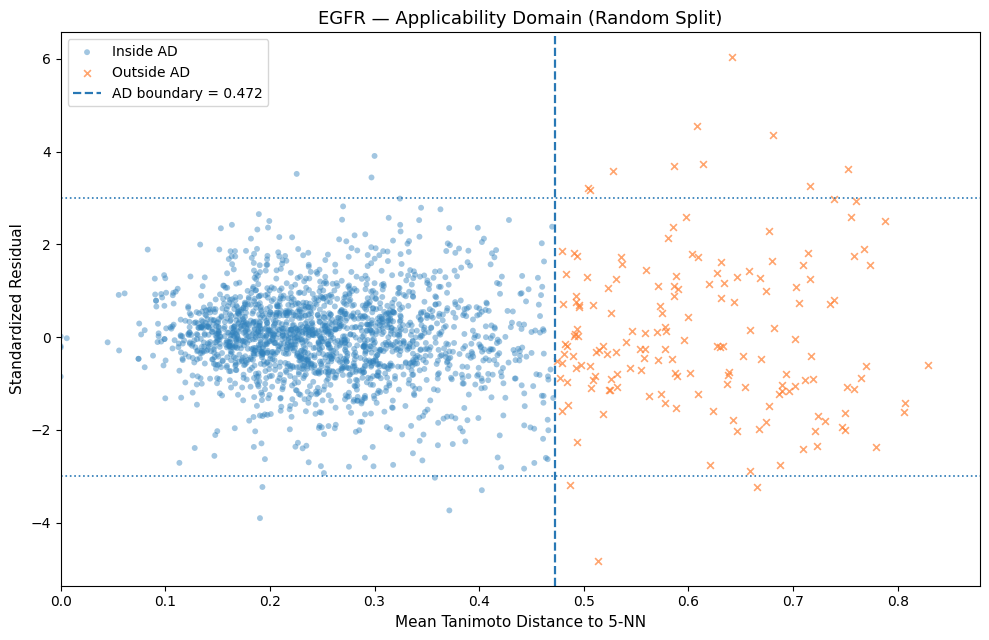

Saved: D:\1. UNIV\1. Materi Univ\TUGAS AKHIR\TA\Source Code\analysis_outputs\applicability_domain\figures\EGFR_random_AD.png
Saved: D:\1. UNIV\1. Materi Univ\TUGAS AKHIR\TA\Source Code\analysis_outputs\applicability_domain\figures\EGFR_random_AD.svg


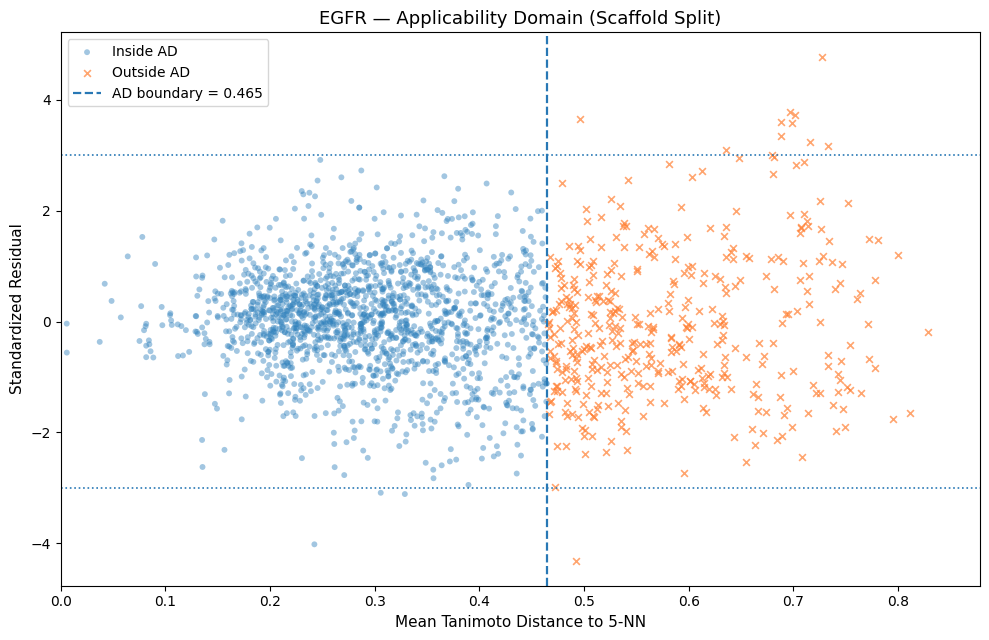

Saved: D:\1. UNIV\1. Materi Univ\TUGAS AKHIR\TA\Source Code\analysis_outputs\applicability_domain\figures\EGFR_scaffold_AD.png
Saved: D:\1. UNIV\1. Materi Univ\TUGAS AKHIR\TA\Source Code\analysis_outputs\applicability_domain\figures\EGFR_scaffold_AD.svg


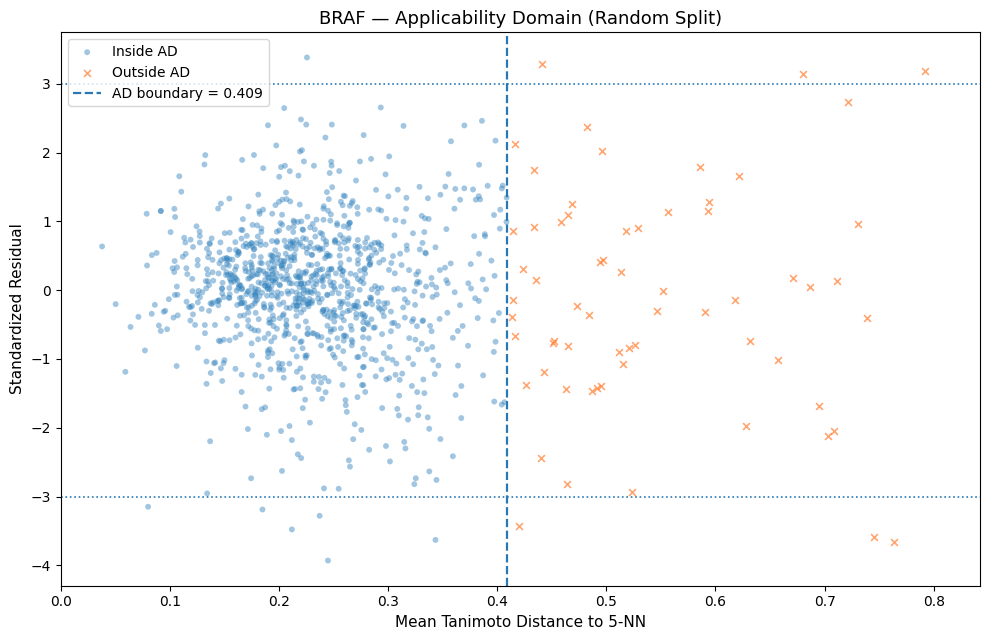

Saved: D:\1. UNIV\1. Materi Univ\TUGAS AKHIR\TA\Source Code\analysis_outputs\applicability_domain\figures\BRAF_random_AD.png
Saved: D:\1. UNIV\1. Materi Univ\TUGAS AKHIR\TA\Source Code\analysis_outputs\applicability_domain\figures\BRAF_random_AD.svg


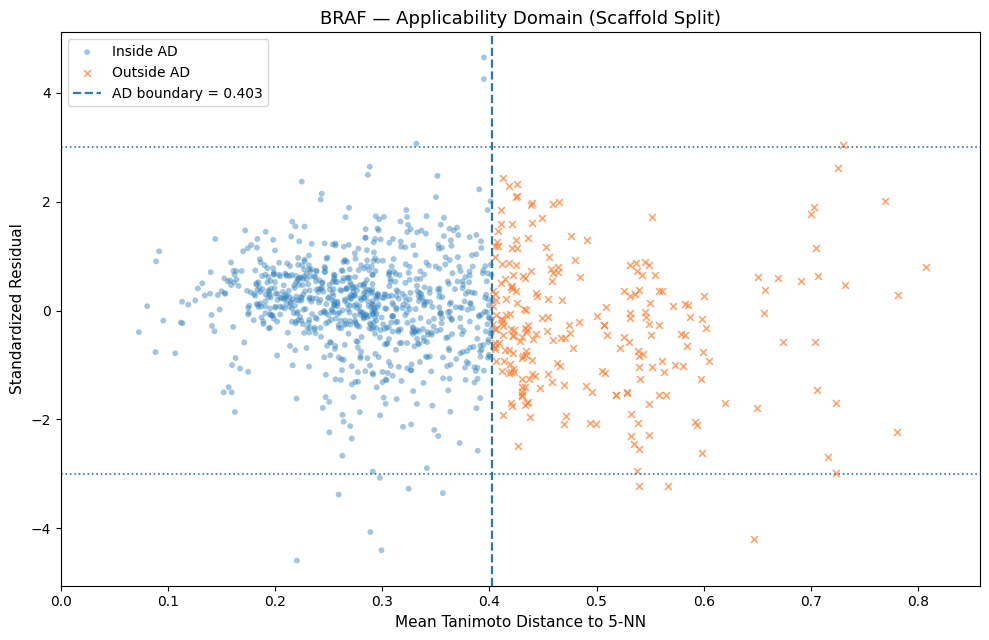

Saved: D:\1. UNIV\1. Materi Univ\TUGAS AKHIR\TA\Source Code\analysis_outputs\applicability_domain\figures\BRAF_scaffold_AD.png
Saved: D:\1. UNIV\1. Materi Univ\TUGAS AKHIR\TA\Source Code\analysis_outputs\applicability_domain\figures\BRAF_scaffold_AD.svg


In [6]:

# ============================================================
# CELL 6 — VISUALIZE APPLICABILITY DOMAIN
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

PLOT_DIR = AD_RESULTS_DIR / "figures"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

for target in ["EGFR", "BRAF"]:
    for split in ["random", "scaffold"]:

        # Ambil hasil senyawa testing untuk target dan split
        plot_df = ad_compounds_df[
            (ad_compounds_df["Target"] == target)
            & (ad_compounds_df["Split"] == split)
        ].copy()

        if plot_df.empty:
            print(f"Data tidak ditemukan: {target} - {split}")
            continue

        # Hitung residual dan standardized residual
        residuals = (
            plot_df["y_true_pIC50"].to_numpy()
            - plot_df["y_pred_pIC50"].to_numpy()
        )

        residual_std = residuals.std(ddof=0)

        if residual_std == 0:
            std_residuals = np.zeros_like(residuals)
        else:
            std_residuals = (
                residuals - residuals.mean()
            ) / residual_std

        # Data sumbu X dan status AD
        distances = plot_df[
            "Mean_Tanimoto_Distance_k5"
        ].to_numpy()

        inside = plot_df["AD_Status"].eq(
            "Inside AD"
        ).to_numpy()

        outside = ~inside

        threshold = float(
            plot_df["AD_Threshold"].iloc[0]
        )

        # ----------------------------------------------------
        # Plot
        # ----------------------------------------------------
        fig, ax = plt.subplots(figsize=(10, 6.5))

        # Inside AD
        ax.scatter(
            distances[inside],
            std_residuals[inside],
            s=18,
            alpha=0.45,
            color="#3182BD",
            marker="o",
            edgecolors="none",
            label="Inside AD"
        )

        # Outside AD
        ax.scatter(
            distances[outside],
            std_residuals[outside],
            s=24,
            alpha=0.70,
            color="#FF7F32",
            marker="x",
            linewidths=1.2,
            label="Outside AD"
        )

        # AD boundary
        ax.axvline(
            x=threshold,
            color="#2878B5",
            linestyle="--",
            linewidth=1.6,
            label=f"AD boundary = {threshold:.3f}"
        )

        # Residual warning limits
        ax.axhline(
            y=3,
            color="#2878B5",
            linestyle=":",
            linewidth=1.2
        )

        ax.axhline(
            y=-3,
            color="#2878B5",
            linestyle=":",
            linewidth=1.2
        )

        ax.set_xlabel(
            "Mean Tanimoto Distance to 5-NN",
            fontsize=11
        )

        ax.set_ylabel(
            "Standardized Residual",
            fontsize=11
        )

        ax.set_title(
            f"{target} — Applicability Domain ({split.capitalize()} Split)",
            fontsize=13
        )

        ax.set_xlim(
            left=0,
            right=min(
                1.0,
                max(distances.max(), threshold) + 0.05
            )
        )

        ax.legend(loc="upper left", frameon=True)
        ax.grid(False)

        fig.tight_layout()

        # Simpan PNG dan SVG
        filename = f"{target}_{split}_AD"

        png_path = PLOT_DIR / f"{filename}.png"
        svg_path = PLOT_DIR / f"{filename}.svg"

        fig.savefig(
            png_path,
            dpi=300,
            bbox_inches="tight"
        )

        fig.savefig(
            svg_path,
            bbox_inches="tight"
        )

        plt.show()
        plt.close(fig)

        print(f"Saved: {png_path}")
        print(f"Saved: {svg_path}")
